# Import Libraries and Dataset

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv('nfl_season_ticket_churn_data.csv')

# Exploratory Data Analysis (EDA)

In [23]:
df.shape

(1000, 15)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   account_id                     1000 non-null   object 
 1   tenure_years                   1000 non-null   int64  
 2   seat_tier                      1000 non-null   object 
 3   seat_count                     1000 non-null   int64  
 4   total_annual_ticket_spend      1000 non-null   int64  
 5   games_scheduled                1000 non-null   int64  
 6   games_attended                 1000 non-null   int64  
 7   ticket_utilization_pct         1000 non-null   float64
 8   secondary_resale_pct           1000 non-null   float64
 9   total_season_concession_spend  1000 non-null   float64
 10  rep_touchpoints_count          1000 non-null   int64  
 11  complaints_logged              1000 non-null   int64  
 12  customer_satisfaction_score    795 non-null    fl

In [25]:
df.describe()

,tenure_years,seat_count,total_annual_ticket_spend,games_scheduled,games_attended,ticket_utilization_pct,secondary_resale_pct,total_season_concession_spend,rep_touchpoints_count,complaints_logged,customer_satisfaction_score,team_wins_attended,churned
count,1000.000000,1000.00000,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,795.000000,1000.000000,1000.000000
mean,4.407000,3.20400,5055.820000,9.0,6.953000,77.269700,22.670800,1443.484880,2.96700,0.326000,8.615094,3.840000,0.039000
std,3.865785,1.51548,3684.644044,0.0,1.625864,18.065265,19.971595,1192.806946,1.71839,0.652802,1.209856,1.629434,0.193692
min,1.000000,2.00000,1616.000000,9.0,2.000000,22.200000,0.000000,80.720000,0.00000,0.000000,5.000000,0.000000,0.000000
25%,2.000000,2.00000,3121.750000,9.0,6.000000,66.700000,2.600000,641.532500,2.00000,0.000000,8.000000,3.000000,0.000000
50%,3.000000,2.00000,3477.000000,9.0,7.000000,77.800000,20.800000,1080.270000,3.00000,0.000000,9.000000,4.000000,0.000000
75%,6.000000,4.00000,6599.250000,9.0,8.000000,88.900000,35.725000,1855.997500,4.00000,0.000000,10.000000,5.000000,0.000000
max,30.000000,8.00000,27739.000000,9.0,9.000000,100.000000,85.000000,11648.430000,10.00000,3.000000,10.000000,9.000000,1.000000


In [26]:
df.head()

,account_id,tenure_years,seat_tier,seat_count,total_annual_ticket_spend,games_scheduled,games_attended,ticket_utilization_pct,secondary_resale_pct,total_season_concession_spend,rep_touchpoints_count,complaints_logged,customer_satisfaction_score,team_wins_attended,churned
0,NFL-STH-10000,2,Lower Bowl,2,3362,9,8,88.9,11.1,1378.88,5,0,10.0,5,0
1,NFL-STH-10001,13,Lower Bowl,2,3422,9,9,100.0,0.0,1000.44,2,0,9.0,6,0
2,NFL-STH-10002,6,Upper Bowl,4,3357,9,3,33.3,79.0,491.88,2,0,6.0,2,0
3,NFL-STH-10003,4,Lower Bowl,4,6679,9,8,88.9,20.9,2242.40,2,0,10.0,6,0
4,NFL-STH-10004,1,Lower Bowl,4,6628,9,7,77.8,8.2,1403.15,1,0,9.0,6,0


### Handling Missing Data

In [27]:
# Determine if there is missing data
df.isnull().sum()

account_id                         0
tenure_years                       0
seat_tier                          0
seat_count                         0
total_annual_ticket_spend          0
games_scheduled                    0
games_attended                     0
ticket_utilization_pct             0
secondary_resale_pct               0
total_season_concession_spend      0
rep_touchpoints_count              0
complaints_logged                  0
customer_satisfaction_score      205
team_wins_attended                 0
churned                            0
dtype: int64

In [28]:
# Flag missing values as a distinct feature

df['customer_satisfaction_score_missing'] = df['customer_satisfaction_score'].isnull()


In [29]:
# Check which accounts have no values for customer satisfaction score and their churn status

null_satisfaction_account = df[df['customer_satisfaction_score_missing']][['account_id','churned']]

print(null_satisfaction_account)

        account_id  churned
8    NFL-STH-10008        0
13   NFL-STH-10013        0
15   NFL-STH-10015        0
26   NFL-STH-10026        0
33   NFL-STH-10033        0
..             ...      ...
981  NFL-STH-10981        0
983  NFL-STH-10983        0
984  NFL-STH-10984        0
993  NFL-STH-10993        0
999  NFL-STH-10999        1

[205 rows x 2 columns]


In [30]:
# Amount of churned and non-churned accounts with no customer satisfaction score
# 0 = Renewed for next season, 1 = Did not renew for next season

null_satisfaction_account['churned'].value_counts()

churned
0    192
1     13
Name: count, dtype: int64

### Visualize Churn Distribution

Total Accounts: 1000
Renewed Accounts (0): 961 (96.10%)
Churned Accounts (1): 39 (3.90%)


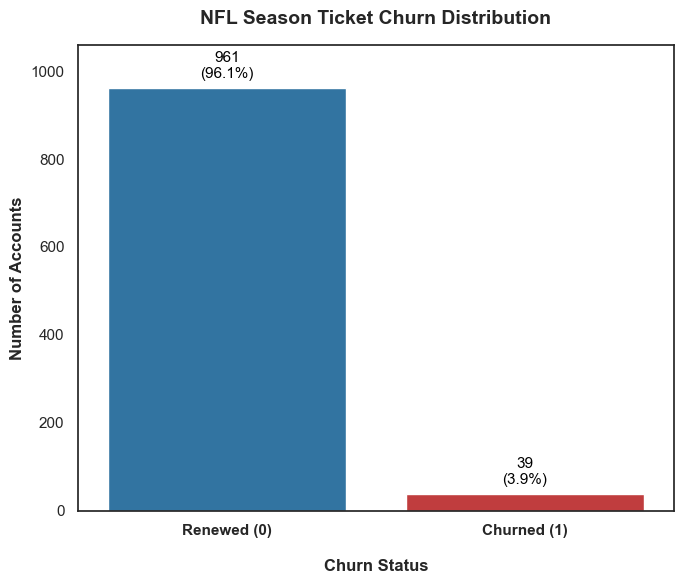

In [31]:
#1. Calculate baseline churn rate programmatically
churn_counts = df['churned'].value_counts()
churn_percentage = df['churned'].value_counts(normalize=True)*100

print(f"Total Accounts: {len(df)}")
print(f"Renewed Accounts (0): {churn_counts[0]} ({churn_percentage[0]:.2f}%)")
print(f"Churned Accounts (1): {churn_counts[1]} ({churn_percentage[1]:.2f}%)")

#2. Create countplot visualization
plt.figure(figsize=(7,6))
sns.set_theme(style = "white")

fig = sns.countplot(x='churned', hue='churned', data=df, palette=['#1f77b4', '#d62728'], legend=False)

#3. Add data labels to the bars
total = len(df)
for f in fig.patches:
    height = int(f.get_height())
    percentage = f'{100 * height / total:.1f}%'
    fig.annotate(f'{height}\n({percentage})',
                 (f.get_x() + f.get_width() / 2., height),
                 xytext=(0,5), textcoords='offset points',
                 ha='center', va='bottom', 
                 fontsize=11, color= 'black')

fig.set_ylim(top=fig.get_ylim()[1] * 1.05)
plt.title('NFL Season Ticket Churn Distribution', fontsize=14, weight='bold', pad=15)
plt.xlabel('Churn Status', fontsize=12, weight='bold', labelpad=15)
plt.ylabel('Number of Accounts', fontsize=12, weight='bold')
plt.xticks([0,1], ['Renewed (0)', 'Churned (1)'], fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

In [32]:
# Retrieve Total Annual Ticket Spend Related to Churn
df.groupby('churned')['total_annual_ticket_spend'].sum()

churned
0    4887574
1     168246
Name: total_annual_ticket_spend, dtype: int64

### Feature Correlation Analysis

Text(0.5, 1.0, 'Correlation Matrix with Churn')

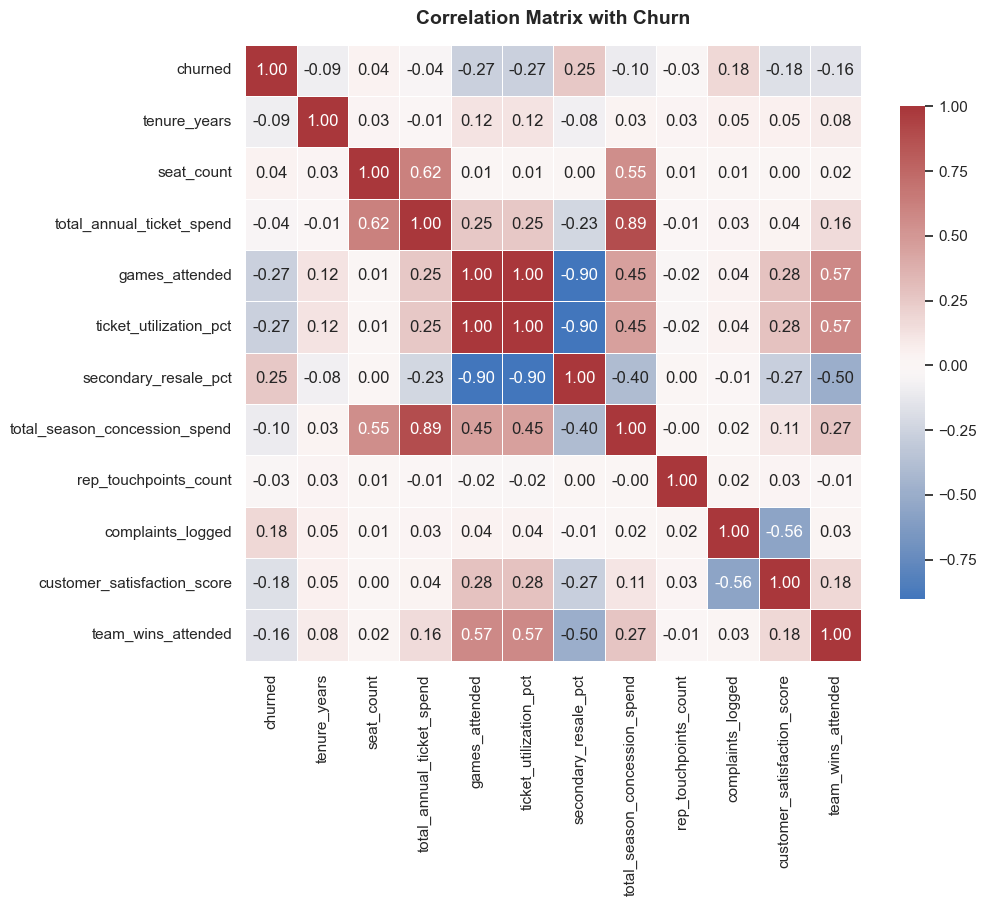

In [33]:
#1. Select numerical columns relevant to churn
numerical_col = [
    'churned',
    'tenure_years',
    'seat_count',
    'total_annual_ticket_spend',
    'games_attended',
    'ticket_utilization_pct',
    'secondary_resale_pct',
    'total_season_concession_spend',
    'rep_touchpoints_count',
    'complaints_logged',
    'customer_satisfaction_score',
    'team_wins_attended']

#2. Complete a Pearson correlation matrix
corr_matrix = df[numerical_col].corr()

#3. Set up visualization canvas
plt.figure(figsize=(10,8))
sns.set_theme(style='white')

#4. Generate heatmap
sns.heatmap(
    corr_matrix,
    annot = True,                   # Display numerical correlation values inside the cell
    fmt = ".2f",                    # Format numbers to 2 decimal places
    cmap = 'vlag',                  # Diverging color palette (blue = negative, red = positive)
    center = 0,                     # Neutral color at zero correlation
    square = True,                  # Force square cells
    linewidths = .5,                # Grid lines between cells
    cbar_kws = {'shrink': .8}       # Scale legend size
)

plt.title('Correlation Matrix with Churn', fontsize = 14, weight = 'bold', pad = 15)

In [34]:
# Retrieve Mean Results on Highly Correlated Results Related to Churn
df.groupby('churned')[['total_annual_ticket_spend','ticket_utilization_pct', 'secondary_resale_pct', 'complaints_logged','customer_satisfaction_score']].mean().round(2).transpose()

churned,0,1
total_annual_ticket_spend,5085.93,4314.00
ticket_utilization_pct,78.24,53.28
secondary_resale_pct,21.66,47.62
complaints_logged,0.30,0.90
customer_satisfaction_score,8.65,7.46


# Rules-Based Risk Scoring Matrix

In [35]:
#1. Create a baseline risk score column for all accounts
df['risk_score'] = 0

#2 Apply CRM Business Rules to assign risk scores based on the following criteria:

#A: Ticket Utilization Percentage below 50% = 30 points
df.loc[df['ticket_utilization_pct'] < 50, 'risk_score'] += 30

#B: Secondary Resale Percentage above 55% = 20 points
df.loc[df['secondary_resale_pct'] > 55, 'risk_score'] += 25

#C: Complaints Logged Greater >= 2
df.loc[df['complaints_logged'] >=2, 'risk_score'] += 25

#D: Customer Satisfcation Score <=4
df.loc[(df['customer_satisfaction_score'] <=4) | (df['customer_satisfaction_score_missing'] == True), 'risk_score'] += 20

#3. Define Risk Tiers Based on Total Risk Score
def assign_risk_tier(score):
    if score >= 80:
        return 'High Risk'
    elif score >=40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

# Apply Function to Create a Categorical Risk Tier Column
df['risk_tier'] = df['risk_score'].apply(assign_risk_tier)

# Convert the Categorical Data Type to Enforce a Logical Order For Plotting
df['risk_tier'] = pd.Categorical(df['risk_tier'], categories=['Low Risk', 'Medium Risk', 'High Risk'], ordered=True)

# Evaluate the Rules-Based Model

In [36]:
#Analyze the Distribution and Financial Impact of Risk Tiers

tier_distribution = df['risk_tier'].value_counts(sort=False).to_frame(name='Account Count')

tier_distribution['AVG Spend ($)'] = (df.groupby('risk_tier', observed=False)['total_annual_ticket_spend'].mean()).round(2)

tier_distribution['Actual Churn Rate (%)'] = (df.groupby('risk_tier', observed=False)['churned'].mean() * 100).round(1)

tier_distribution['Total Revenue Risk ($)'] = df.groupby('risk_tier', observed=False)['total_annual_ticket_spend'].sum()

print("CRM Risk Tier Summary:")
print("-" * 70)
print(tier_distribution)


CRM Risk Tier Summary:
----------------------------------------------------------------------
             Account Count  AVG Spend ($)  Actual Churn Rate (%)  \
risk_tier                                                          
Low Risk               918        5129.45                    2.2   
Medium Risk             80        4102.91                   23.8   
High Risk                2        9374.00                    0.0   

             Total Revenue Risk ($)  
risk_tier                            
Low Risk                    4708839  
Medium Risk                  328233  
High Risk                     18748  


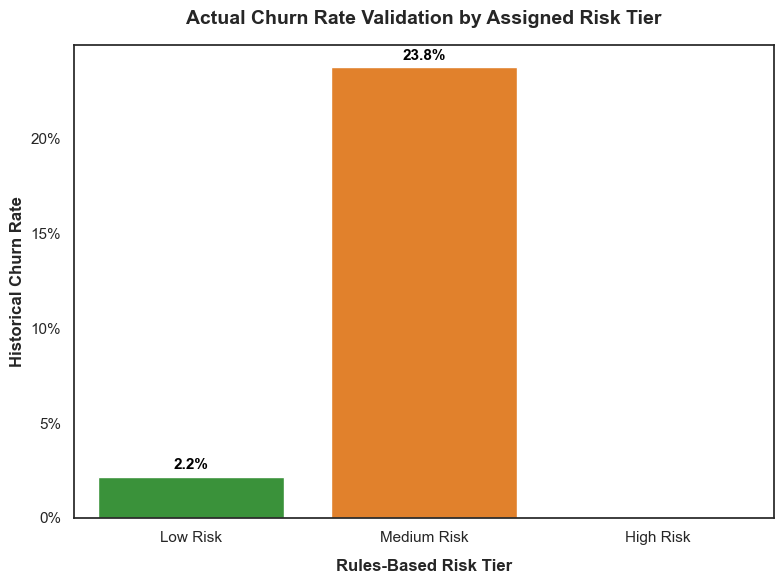

In [37]:
# Visualize Actual Churn Rate by Assigned Risk Tier
plt.figure(figsize=(8,6))
sns.set_theme(style='white')

# Create a Bar Plot Using Actual Historical Churn Data to Validate Our Rules
ax = sns.barplot(
    x='risk_tier',
    y='churned',
    data=df,
    errorbar=None,
    palette=['#2ca02c', '#ff7f0e', '#d62728'],
    hue='risk_tier',
    legend=False
)

plt.title('Actual Churn Rate Validation by Assigned Risk Tier', fontsize=14, weight='bold', pad=15)
plt.xlabel('Rules-Based Risk Tier', fontsize=12, weight='bold', labelpad=10)
plt.ylabel('Historical Churn Rate', fontsize=12, weight='bold')

# Format y-axis as a percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Add percentage labels to the top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1%}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, weight='bold', color='black',
                    xytext=(0,3), textcoords='offset points')

plt.tight_layout()
plt.show()

# Exporting Scored Accounts for CRM Activation

In [38]:
# Filter for Risk Accounts and Export Them to a New CSV
high_risk_accounts = df[df['risk_tier'] == 'High Risk'].sort_values(by='risk_score', ascending=False)
medium_risk_accounts = df[df['risk_tier'] == 'Medium Risk'].sort_values(by='risk_score',ascending = False)

export_cols=[
    'account_id', 'risk_score', 'tenure_years', 'seat_tier',
    'ticket_utilization_pct', 'secondary_resale_pct', 'complaints_logged',
    'customer_satisfaction_score'
]

high_risk_export = high_risk_accounts[export_cols]
medium_risk_export = medium_risk_accounts[export_cols]

high_risk_export.to_csv('high_risk_retention_list.csv', index=False)
medium_risk_export.to_csv('medium_risk_retention_list.csv', index=False)

print(f"Exported {len(high_risk_export)} High Risk Accounts to 'high_risk_retention_list.csv' for immediate rep outreach.")
print(f"Exported {len(medium_risk_export)} Medium Risk Accounts to 'medium_risk_retention_list.csv' for immediate rep outreach.")

Exported 2 High Risk Accounts to 'high_risk_retention_list.csv' for immediate rep outreach.
Exported 80 Medium Risk Accounts to 'medium_risk_retention_list.csv' for immediate rep outreach.
